In [ ]:
# YouTube Comment Analysis - India's Got Latent Season 2

## Objective

The objective of this project is to analyze audience engagement on the YouTube video "India's Got Latent Season 2" using the YouTube Data API v3.

The project involves:
- Collecting comments using the YouTube API
- Storing them in MySQL
- Performing Exploratory Data Analysis (EDA)
- Understanding audience behavior
- Measuring engagement
- Performing sentiment analysis
- Providing business insights for investment decisions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from database import connect_db

In [2]:
conn = connect_db()
query = "SELECT * FROM comments"
df = pd.read_sql(query, conn)
conn.close()
df.head()

C:\Users\Harnoor kaur\AppData\Local\Temp\ipykernel_2772\1485668449.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,comment_id,video_id,author,comment,likes,published_at,reply_count
0,1,UgwBrUCSRnZxFoU-Ph14AaABAg,eHTXQW58WhA,@WAIT_CONTINUES,meanwhile the man in the corner the tough guy ...,0,2026-06-29 05:45:55,0
1,2,UgwZRztprNrwi0e2iRN4AaABAg,eHTXQW58WhA,@pranshukartikey8822,one of the best dancer samay,0,2026-06-29 05:44:37,0
2,3,UgxPxjA1Z3silkg582R4AaABAg,eHTXQW58WhA,@Paras-wd2ij,It has good humour but I just don't feel like ...,1,2026-06-29 05:37:29,0
3,4,UgzZoXXWcGTGNSnr9XV4AaABAg,eHTXQW58WhA,@PawanPandey-j6z8b,Nice one samay ❤,0,2026-06-29 05:32:49,0
4,5,UgzsMcEO-1fWFZnwcQB4AaABAg,eHTXQW58WhA,@whymee-3i,Crazzzzzy bhhai🎉🎉,0,2026-06-29 05:30:41,0


In [3]:
df.info()
df.shape
df.columns
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89955 entries, 0 to 89954
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            89955 non-null  int64         
 1   comment_id    89955 non-null  object        
 2   video_id      89955 non-null  object        
 3   author        89955 non-null  object        
 4   comment       89955 non-null  object        
 5   likes         89955 non-null  int64         
 6   published_at  89955 non-null  datetime64[ns]
 7   reply_count   89955 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 5.5+ MB


np.int64(0)

In [4]:
print("Total Comments :", len(df))

print("Unique Authors :", df["author"].nunique())

print("Average Likes :", df["likes"].mean())

print("Maximum Likes :", df["likes"].max())

zero_like = (df["likes"] == 0).sum()

print("Zero Like Comments :", zero_like)

Total Comments : 89955
Unique Authors : 79850
Average Likes : 15.357234172641876
Maximum Likes : 237024
Zero Like Comments : 68301


In [5]:
df["author"].value_counts().head(10)

author
@RavishankarChoudhary9    72
@SKELETON_WALLAH          28
@1404-s1n                 25
@suhailsiddiqui249        23
@KareenaSouthie           22
@TheSleeksociety          21
@jigartailor1439          21
@rezaulkarim-py2gn        20
@Ashishjha-r7r            18
@OP_AR_Rahman             18
Name: count, dtype: int64

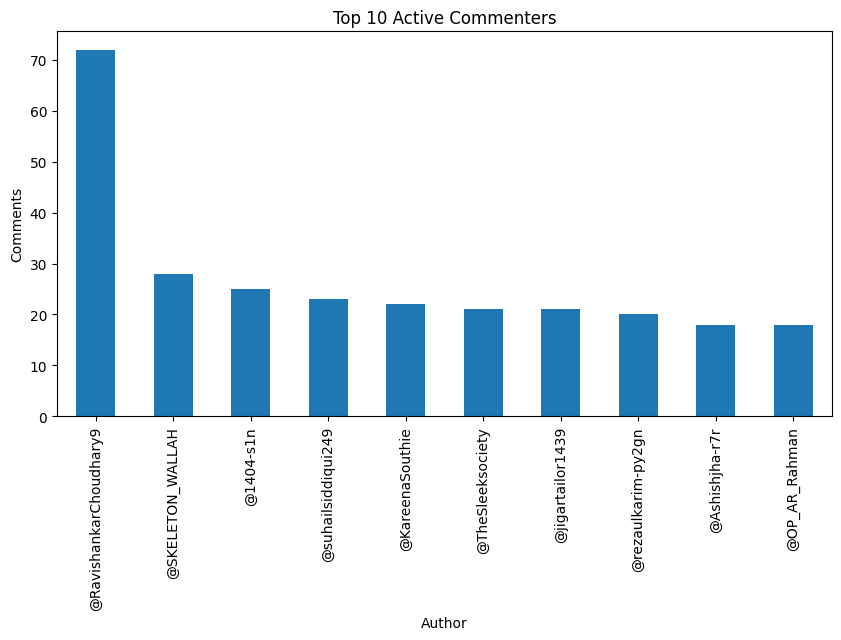

In [7]:
top_users = df["author"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_users.plot(kind="bar")

plt.title("Top 10 Active Commenters")

plt.xlabel("Author")

plt.ylabel("Comments")

plt.xticks(rotation=90)

plt.show()

In [8]:
df.nlargest(10, "likes")[["author", "likes", "comment"]]

,author,likes,comment
76013,@ashishsolanki_1,237024,Mai police ki taraf se hi aaya tha.
43156,@Amritsingh0077,76499,Bring That Trump In the Panel😭💀
78590,@FootnBallzz,72291,That Drunk guy lowkey gave me goosebumps when ...
44451,@smitparikh781,66585,"The people who have watched 1st season, know h..."
55066,@Vlogopinion0102,55225,First ever hit show jiska channel pe season 1 ...
81708,@seckyg171,51517,donald trump guy was fab!!!!😭😭
61261,@mehek6084,47661,For the first time bollywood celebrities were ...
53673,@svivekvardhan66,47487,doland trump first ever guy to dominate samay ...
78412,@Vicky613,35023,"Anyone read the disclaimer?\n""This video is no..."
20938,@Driftiq-n4e,32089,Trump had more confidence than the entire pane...


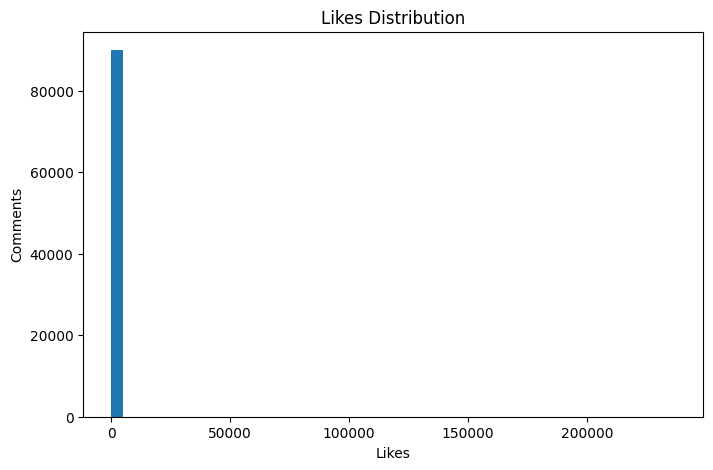

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["likes"], bins=50)

plt.title("Likes Distribution")

plt.xlabel("Likes")

plt.ylabel("Comments")

plt.show()

In [11]:
df["published_at"] = pd.to_datetime(df["published_at"])
comments_per_day = df.groupby(df["published_at"].dt.date).size()

comments_per_day

published_at
2026-06-20    53913
2026-06-21    22109
2026-06-22     6362
2026-06-23     2790
2026-06-24     1664
2026-06-25     1055
2026-06-26      790
2026-06-27      691
2026-06-28      530
2026-06-29       51
dtype: int64

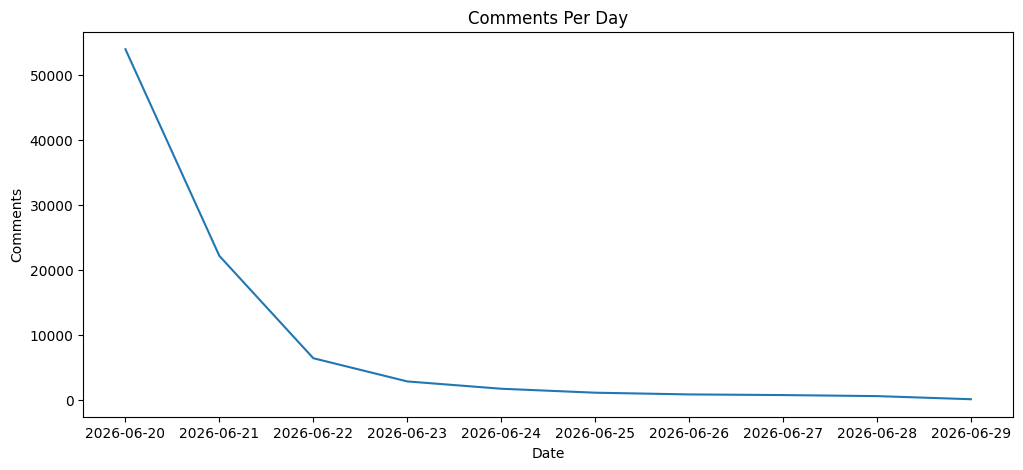

In [12]:
comments_per_day.plot(figsize=(12,5))

plt.title("Comments Per Day")

plt.xlabel("Date")

plt.ylabel("Comments")

plt.show()

In [13]:
comments_per_hour = df.groupby(df["published_at"].dt.hour).size()

comments_per_hour

published_at
0      751
1     1008
2     1377
3     1816
4     2124
5     2579
6     3228
7     2844
8     2756
9     2568
10    2320
11    1870
12    1744
13    5067
14    8637
15    9052
16    9207
17    8870
18    7583
19    5381
20    4152
21    2522
22    1548
23     951
dtype: int64

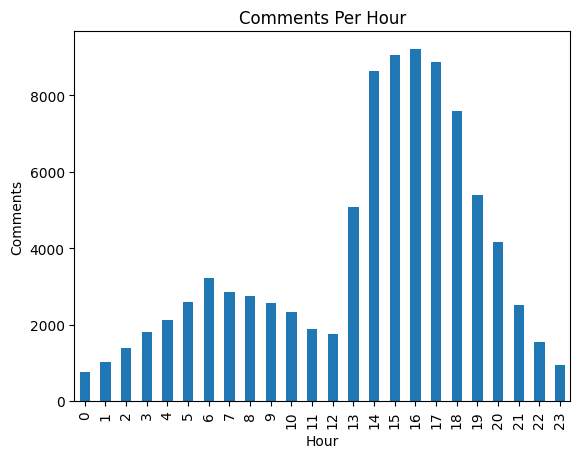

In [14]:
comments_per_hour.plot(kind="bar")

plt.title("Comments Per Hour")

plt.xlabel("Hour")

plt.ylabel("Comments")

plt.show()

In [15]:
df["comment_length"] = df["comment"].str.len()

df["comment_length"].describe()

count    89955.000000
mean        45.685409
std         67.864958
min          0.000000
25%         20.000000
50%         33.000000
75%         54.000000
max       7296.000000
Name: comment_length, dtype: float64

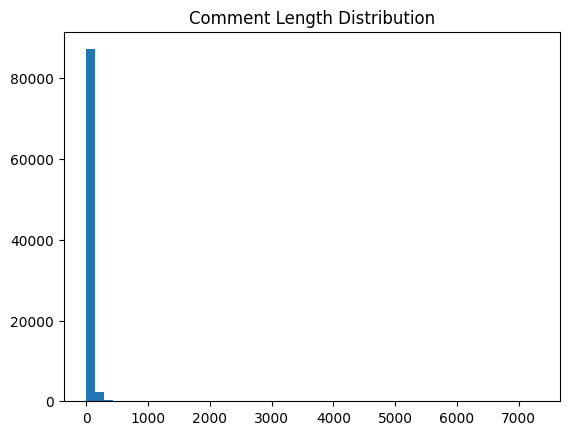

In [16]:
plt.hist(df["comment_length"], bins=50)

plt.title("Comment Length Distribution")

plt.show()